# S11-1 bondlabライブラリの整理とテスト（Capstone）

## 学習目標

- `bondlab` の13層（data / rates / daycount / bond / curve / analytics / risk /
  sim / models / pricing / credit / mbs / bt）の依存の向きを図示し、下位から
  上位への一方向依存に保った理由を、変更の影響範囲とテスト容易性の観点で説明できる
- 単体テスト・回帰テスト・QuantLib 突合の3層からなるテスト戦略と、
  セマンティックバージョニングによる後方互換の約束を、採用担当者に説明できる
- カーブ構築から債券・金利モデル・スワップション・CDS・バックテストまでを、
  すべて `bondlab` の1つの名前空間からの import で貫くエンドツーエンドの
  ワークフローを、1本の物語として実行できる
- 主要な数値が QuantLib と機械精度で一致することを一覧表で示し、`pytest` の
  全テスト緑を notebook 内で再現して、ライブラリが「動く状態」であることを証拠立てできる

## 実務での位置づけ（ファンドはどう稼ぐか）

デスクにとって `bondlab` のような自作ライブラリは「見た目のよいコード」ではなく、値付けとリスク計測の土台そのものです。トレーダーが顧客へ返す bid/ask、リスク管理が毎晩回す DV01・KRD・VaR、フロントクオンツがキャリブレーションするモデル出力は、すべて同じカーブ構築・債券評価・割引の関数群を経由します。ここで数値が一つずれれば、その誤差はクォート・在庫評価・損益（PnL）へ連鎖して伝播します。全層を1つの名前空間から貫き、カーブから債券・金利モデル・スワップション・CDS・バックテストまでを1本の物語として通す本 notebook は、その「壊れると全部が壊れる中枢」を自分の手で組み上げて見せる回です。

下位から上位への一方向依存という設計判断は、実務では「変更の影響範囲を予測可能にする」という価値に直結します。日数計算やカーブの修正が上位の分析・リスク層をどこまで揺らすかが依存グラフから読めるので、本番の値付けエンジンを止めずに直せます。QuantLib との機械精度突合は、社内では独立チームによる**モデルバリデーション**（FRB SR 11-7 の枠組み）に相当し、「そのモデルで顧客に値を出してよい」という承認の証拠になります。単体・回帰・突合の3層テストとセマンティックバージョニングは、リリースのたびに既存の値付けが変わらないことを保証する仕組みで、静かなミスプライスによる損失を未然に防ぎます。

就職の観点では、この notebook は志望職を横断する共通の武器になります。銀行の金利デスククオンツ（S2/S5/S6）にはカーブとモデルを自作した証拠として、リスク管理・モデルバリデーション（S3/S5-5）には「独立に検証し承認する」作法を理解している証拠として、そのまま提示できます。面接で「あなたのライブラリは QuantLib と一致しますか、テストは緑ですか」と問われたとき、この一覧表と `pytest` の再現を見せられること自体が、口頭の説明を超えた説得力になります。


## 理論（設計）

S0 から S10 まで、各シリーズは対応する層だけを触りながら `bondlab` を育ててきた。
Capstone はその全体を俯瞰し、レイヤー設計の判断を言語化する回である。実装の
詳細は各シリーズで済んでいるので、ここでは「なぜこの形なのか」を扱う。

### レイヤーと依存の向き

層は下から上へ一方向にだけ依存する。上位層は下位層を import してよいが、
下位層は上位層を知らない。各層がどのシリーズで作られたかも併記する。

| 層 | 役割 | 直接依存する下位層 | 構築シリーズ |
|---|---|---|---|
| `data` | 市場データ取得・キャッシュ（`.env`・cache_only） | （外部のみ: pandas） | S0-2 |
| `rates` | 複利規約変換・割引係数の往復 | （外部のみ: numpy） | S1-1 |
| `daycount` | 日数計算規約（ACT/360・30/360・ACT/ACT） | （外部のみ） | S1-2 |
| `bond` | 固定利付債の価格・YTM・経過利子 | `daycount` | S1-3/1-4 |
| `curve` | 割引カーブ・ブートストラップ・NSS | （外部のみ: numpy） | S2 |
| `analytics` | デュレーション・DV01・KRD・PCA | `curve` | S3-1〜3-4 |
| `risk` | VaR / ES・Kupiec 検定 | （外部のみ: scipy） | S3-5 |
| `sim` | ブラウン運動・SDE 数値解・分散削減 | （外部のみ: numpy/scipy） | S4 |
| `models` | 短期金利モデル（Vasicek/CIR/HullWhite） | `curve` | S5 |
| `pricing` | スワップ・キャップ・スワップション・SABR | `curve`（数値のみ） | S6 |
| `credit` | ハザード・CDS・Merton | `curve`（数値のみ） | S7 |
| `mbs` | プリペイメント・パススルー CF | （外部のみ: numpy） | S8 |
| `bt` | 戦略バックテスト・先物ヘルパ | （外部のみ: pandas） | S9 |

依存グラフを矢印で描くと次のようになる（`A -> B` は「A が B に依存」）。

```
bond      -> daycount
analytics -> curve
models    -> curve
```

それ以外の層は他の `bondlab` 層に依存せず、外部ライブラリ（numpy/scipy/pandas）
の上に直接立つ。層間の内部エッジはこの3本だけで、閉路を持たない有向非巡回
グラフ（DAG）である。閉路が無いことは演習2で import を機械的に走査して確認する。

### なぜ層に分けたか

分割の狙いは二つある。第一に**変更の影響範囲の局所化**である。たとえば
`daycount` の 30/360 実装を直しても、影響が及ぶのは `daycount` に依存する
`bond`（とそのテスト）だけで、`curve` や `models` は巻き込まれない。層をまたぐ
依存を下向き一方向に限れば、変更の波及は「自分より上」だけを見れば読み切れる。

第二に**部品としての再利用**である。`curve.DiscountCurve` は `analytics`（KRD）・
`models`（HullWhite の初期カーブ）・`pricing`（割引）・`credit`（リスキー割引）が
共通に使う。1つの割引カーブ抽象を全層が共有するので、カーブ構築を差し替えれば
下流のすべての評価が一貫して追随する。逆に依存を双方向に許すと、`curve` を直すと
`models` が壊れ、`models` を直すと `curve` が壊れる、という循環に陥る。

### テスト戦略：単体・回帰・QuantLib 突合

`tests/` は3種類の役割を1つの `pytest` スイートに束ねている。

| 種別 | 目的 | 例 |
|---|---|---|
| 単体テスト（unit test） | 関数の入出力が仕様どおりか | `rates` の往復変換、`bond` の price↔yield 往復 |
| 回帰テスト（regression test） | 過去に直したバグが再発しないか | `bond` の ACT/ACT うるう年境界（ISDA 比バグの回帰防止） |
| QuantLib 突合 | 定評ある実装と数値が一致するか | Vasicek/CIR の ZCB、Black'76、CDS フェアスプレッド |

QuantLib 突合を軸に置く理由は、自作実装の「正しさ」を外部の権威で担保できる
ためである。面接で問われるのはモデルを導出・実装できるかであって、QuantLib を
呼べるかではない。だから QuantLib は評価役ではなく**検証役**に徹し、機械精度の
一致（`< 1e-10` 等）を回帰テストとして固定する。

### セマンティックバージョニング

`pyproject.toml` の `version` は `MAJOR.MINOR.PATCH` の三つ組で意味を持たせる
（semantic versioning）。MAJOR は後方互換を壊す変更、MINOR は後方互換な機能
追加、PATCH はバグ修正に対応させる。読者・利用者は「MINOR 更新なら既存の
呼び出しは壊れない」と読めるので、更新を安全に取り込める。現在は初期開発段階を
示す `0.y.z` で、公開 API はまだ固まっていない（`0.x` では MINOR でも破壊的変更が
許容される慣行）。API を凍結して外部に約束する段になったら `1.0.0` を切る。

### 設計判断を文書に残す意義

「なぜ層を下向き一方向にしたか」「なぜ QuantLib を検証役に限ったか」は、コードを
読むだけでは復元できない。判断の背景を残さないと、後任（半年後の自分を含む）が
同じ検討を一からやり直すか、意図を誤読して層をまたぐ近道を入れ、循環を生む。
本 notebook はライブラリ全体の実演を兼ねた設計記録（design record）であり、
併せて `docs/bondlab_api.md`（層ごとの公開 API 一覧）を残す。両者があれば、
採用担当者は「何ができるか」を API リファレンスで、「なぜこの形か」を本 notebook で
追える。

## スクラッチ/実演

カーブ構築 → 債券 → 金利モデル → スワップション → CDS → バックテストを、
1本の物語として通す。すべて `bondlab` という1つのパッケージからの import だけで
繋がることを、最初の import ブロックで示す。合成データのみを使い、乱数は固定する。

### 使用する自作関数（この notebook で定義するヘルパ）

| 関数 | 引数 | 返り値 | 役割 |
|---|---|---|---|
| `synthetic_par_curve(tenors)` | テナー配列（年） | パー利回り配列 | NSS 形の合成パー利回りを決定的に生成 |
| `ql_fixed_bond(bond)` | `FixedRateBond` | `ql.FixedRateBond` | 同一スケジュールの QuantLib 債券を組む（突合用） |
| `abs_diff(a, b)` | 数値2つ | `float` | 突合表のための絶対差 |

In [1]:
import os

os.environ.setdefault("MPLBACKEND", "Agg")

import datetime as dt
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["Hiragino Sans", "Yu Gothic", "Meiryo", "IPAexGothic", "Noto Sans CJK JP", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
# --- bondlab の全層を1つの名前空間から import する（層が繋がっている証拠） ---
import bondlab
from bondlab import data                          # S0: 市場データ層
from bondlab import rates, daycount               # S1: 金利・日数
from bondlab.bond import FixedRateBond            # S1: 債券
from bondlab.curve import bootstrap_par, DiscountCurve, fit_nss  # S2: カーブ
from bondlab.analytics import duration_convexity  # S3: リスク指標
from bondlab.risk import historical_var, historical_es          # S3: VaR/ES
from bondlab.models import Vasicek, HullWhite     # S5: 金利モデル
from bondlab import pricing                       # S6: デリバティブ
from bondlab.credit import bootstrap_hazard, cds_par_spread, HazardCurve  # S7: クレジット
from bondlab import bt                            # S9: バックテスト

import QuantLib as ql

np.random.seed(0)
RNG = np.random.default_rng(0)

SETTLEMENT = dt.date(2026, 7, 1)
BP = 1e-4

print("bondlab version :", bondlab.__version__)
print("QuantLib version:", ql.__version__)
print("読み込んだ層     : rates, daycount, bond, curve, analytics, risk, models, pricing, credit, bt")

bondlab version : 0.0.1
QuantLib version: 1.42.1
読み込んだ層     : rates, daycount, bond, curve, analytics, risk, models, pricing, credit, bt


### ① 合成パー利回りからカーブをブートストラップ（curve 層）

Nelson-Siegel-Svensson 形の合成パー利回りを、等間隔（1年刻み）の年次グリッドで
作る。`bootstrap_par` は等間隔グリッドを前提に、各テナーのパー債価格が額面に
なる条件から割引係数を逐次剥ぎ取る。以降のすべての評価はこの1本のカーブを共有する。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


テナー :  1y  2y  3y  4y  5y  6y  7y  8y  9y 10y ...
パー(%) : 1.87 2.20 2.43 2.60 2.72 2.81 2.87 2.92 2.96 2.99 ...
割引係数 DF(5y)=0.873715  DF(10y)=0.742886  DF(30y)=0.391868
ゼロレート z(10y)=2.9721%  フォワード f(5y,10y)=3.2442%


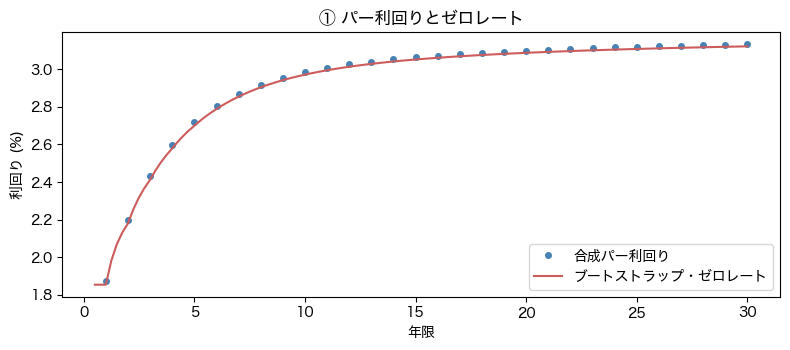

In [2]:
def synthetic_par_curve(tenors):
    """NSS 形の合成パー利回りを決定的に生成する（単位: 小数, 例 0.02=2%）。

    右肩上がりで長期に収束する現実的なカーブ形状。市場データではなく教材用の
    決定的な合成値なので、乱数も外部データも使わない。
    """
    beta0, beta1, beta2, lam = 0.032, -0.018, 0.010, 2.5
    tau = np.asarray(tenors, dtype=float)
    load = (1 - np.exp(-tau / lam)) / (tau / lam)
    return beta0 + beta1 * load + beta2 * (load - np.exp(-tau / lam))


tenors = np.arange(1.0, 31.0)                 # 等間隔グリッド（1〜30年）
par = synthetic_par_curve(tenors)
curve = bootstrap_par(tenors, par, frequency=1, interp="log_linear")

print("テナー :", " ".join(f"{int(t):>2d}y" for t in tenors[:10]), "...")
print("パー(%) :", " ".join(f"{p*100:>4.2f}" for p in par[:10]), "...")
print(f"割引係数 DF(5y)={curve.discount(5.0):.6f}  DF(10y)={curve.discount(10.0):.6f}  DF(30y)={curve.discount(30.0):.6f}")
print(f"ゼロレート z(10y)={curve.zero_rate(10.0)*100:.4f}%  フォワード f(5y,10y)={curve.forward_rate(5.0,10.0)*100:.4f}%")

fig, ax = plt.subplots(figsize=(8, 3.6))
grid = np.linspace(0.5, 30, 120)
ax.plot(tenors, par * 100, "o", ms=4, color="steelblue", label="合成パー利回り")
ax.plot(grid, curve.zero_rate(grid) * 100, "-", color="indianred", label="ブートストラップ・ゼロレート")
ax.set_xlabel("年限")
ax.set_ylabel("利回り (%)")
ax.set_title("① パー利回りとゼロレート")
ax.legend()
fig.tight_layout()
plt.show()

### ② 固定利付債の価格・YTM・デュレーション（bond / analytics 層）

10年の固定利付債を1本組み、`bond` 層で clean price と YTM を、`analytics` 層で
修正デュレーション・コンベクシティ・DV01 を求める。価格→利回りの往復が
一致することを `assert` で守る。

In [3]:
bond = FixedRateBond(
    issue=dt.date(2024, 6, 15),
    maturity=dt.date(2031, 6, 15),
    coupon=0.018,
    frequency=2,
    convention="ACT/ACT",
)
ytm = 0.021
clean = bond.clean_price(ytm, SETTLEMENT)
accrued = bond.accrued(SETTLEMENT)
y_back = bond.yield_from_price(clean, SETTLEMENT)
dc = duration_convexity(bond, ytm, SETTLEMENT)

print(f"clean price          = {clean:.6f}")
print(f"経過利子 accrued     = {accrued:.6f}")
print(f"YTM(価格から逆算)    = {y_back*100:.6f}%   （入力 {ytm*100:.4f}% と一致）")
print(f"修正デュレーション   = {dc['modified']:.6f} 年")
print(f"コンベクシティ       = {dc['convexity']:.6f}")
print(f"DV01                 = {dc['dv01']:.6f}（額面100あたり1bpの価格変化）")
assert abs(y_back - ytm) < 1e-10
print("price ↔ yield 往復一致")

clean price          = 98.594491
経過利子 accrued     = 0.078689
YTM(価格から逆算)    = 2.100000%   （入力 2.1000% と一致）
修正デュレーション   = 4.709094 年
コンベクシティ       = 25.085511
DV01                 = 0.046466（額面100あたり1bpの価格変化）
price ↔ yield 往復一致


### ③ 短期金利モデルのゼロクーポン債（models 層）

アフィンモデルの Vasicek は ZCB を解析的に持つ。市場整合の Hull-White は
①のカーブを初期条件に取り、$t=0$ で市場割引係数を厳密に再現する。同じ
`curve` オブジェクトを Hull-White の初期カーブに渡す点が、層が繋がっている実演。

In [4]:
vas = Vasicek(a=0.30, b=0.030, sigma=0.015, r0=0.020)
hw = HullWhite(a=0.05, sigma=0.010, curve=curve)

taus = np.array([1.0, 5.0, 10.0, 30.0])
print(f"{'tau':>4} {'Vasicek ZCB':>14} {'HW ZCB(t=0)':>14} {'市場 DF':>12}")
for tau in taus:
    print(f"{tau:>4.0f} {vas.zcb(tau):>14.8f} {hw.zcb(0.0, tau):>14.8f} {curve.discount(tau):>12.8f}")
# Hull-White は初期カーブを再現する（設計上の要請）。
for tau in taus:
    assert abs(hw.zcb(0.0, tau) - curve.discount(tau)) < 1e-10
print("Hull-White は t=0 で市場カーブを厳密再現")

 tau    Vasicek ZCB    HW ZCB(t=0)        市場 DF
   1     0.97889541     0.98164019   0.98164019
   5     0.88483982     0.87371511   0.87371511
  10     0.76976769     0.74288615   0.74288615
  30     0.43369240     0.39186800   0.39186800
Hull-White は t=0 で市場カーブを厳密再現


### ④ スワップション（pricing 層）

①のカーブから 5y5y のフォワードスワップレートとアニュイティを求め、その上で
ペイヤースワップションを Black'76 で評価する。割引・フォワードは `curve` 層、
ボラは市場から与える、という層の分担がそのまま式に現れる。

In [5]:
swap_pay_times = np.arange(6.0, 11.0)              # 5y スタート・5y テナー（年次）
fwd_swap = pricing.par_swap_rate(curve, curve, swap_pay_times, start=5.0)
annuity = pricing.swap_annuity(curve, swap_pay_times, start=5.0)
expiry, vol = 5.0, 0.24
strike = fwd_swap                                   # ATM
payer = pricing.swaption_black(fwd_swap, strike, expiry, vol, annuity, option="payer")
receiver = pricing.swaption_black(fwd_swap, strike, expiry, vol, annuity, option="receiver")

print(f"5y5y フォワードスワップレート = {fwd_swap*100:.4f}%")
print(f"アニュイティ                 = {annuity:.6f}")
print(f"ATM ペイヤースワップション   = {payer:.6f}")
print(f"ATM レシーバースワップション = {receiver:.6f}")
# ATM ではペイヤー = レシーバー（プット・コール対称）。
assert abs(payer - receiver) < 1e-12
print("ATM でペイヤー=レシーバー（対称性）")

5y5y フォワードスワップレート = 3.2974%
アニュイティ                 = 3.967649
ATM ペイヤースワップション   = 0.027677
ATM レシーバースワップション = 0.027677
ATM でペイヤー=レシーバー（対称性）


### ⑤ CDS ハザードのブートストラップ（credit 層）

①のカーブを割引に使い、CDS パースプレッドの期間構造から区分定数ハザードカーブを
剥ぎ取る。剥ぎ取ったハザードで再計算したスプレッドが入力に戻ることを確認する
（ブートストラップの整合）。割引は `curve` 層、生存確率は `credit` 層、と分担する。

In [6]:
cds_tenors = np.array([1.0, 3.0, 5.0, 7.0, 10.0])
cds_spreads = np.array([70, 95, 120, 135, 150.0]) * BP   # bp → 小数
hazard = bootstrap_hazard(curve, cds_tenors, cds_spreads, recovery=0.4, freq=4)
recon = np.array([cds_par_spread(hazard, curve, T, 0.4, 4) for T in cds_tenors])

print(f"{'tenor':>6} {'入力(bp)':>10} {'ハザード(%)':>12} {'再計算(bp)':>12} {'生存確率':>10}")
for T, s_in, lam, s_re in zip(cds_tenors, cds_spreads, hazard.hazards, recon):
    print(f"{T:>6.0f} {s_in*1e4:>10.2f} {lam*100:>12.4f} {s_re*1e4:>12.2f} {hazard.survival(T):>10.4f}")
assert np.allclose(recon, cds_spreads, atol=1e-10)
print("ブートストラップ整合：再計算スプレッドが入力に一致")

 tenor     入力(bp)      ハザード(%)      再計算(bp)       生存確率
     1      70.00       1.1640        70.00     0.9884
     3      95.00       1.7985        95.00     0.9535
     5     120.00       2.6973       120.00     0.9034
     7     135.00       2.9994       135.00     0.8508
    10     150.00       3.2776       150.00     0.7712
ブートストラップ整合：再計算スプレッドが入力に一致


### ⑥ 戦略バックテスト（bt 層）

2資産（例: 5年債と30年債の DV01 調整済み損益）に対する単純なタイムシリーズ・
モメンタム戦略を、`bt.backtest` で1期ラグ約定・取引コスト込みで評価する。
シグナルは翌営業日に約定するので先読みは起きない。

findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


...

findfont: Font family 'Noto Sans CJK JP' not found.


findfont: Font family 'Yu Gothic' not found.


findfont: Font family 'Meiryo' not found.


findfont: Font family 'Noto Sans CJK JP' not found.


年率リターン   = -0.1413
年率ボラ       = 1.6164
シャープレシオ = -0.087
最大ドローダウン = -2.5512
勝率           = 0.482   取引日数 = 500
日次 99% VaR   = 0.2486
日次 99% ES    = 0.2801


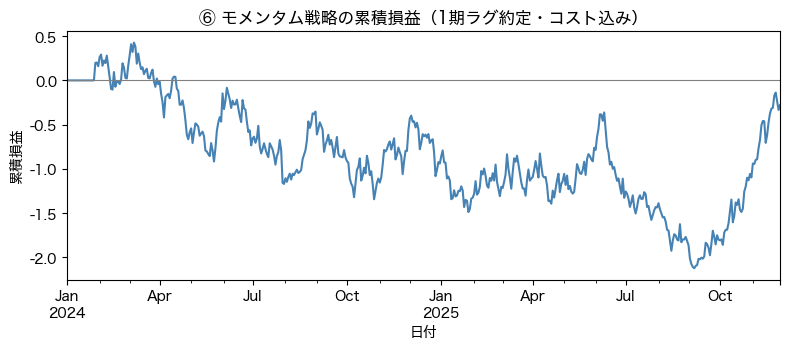

In [7]:
n_days = 500
dates = pd.bdate_range("2024-01-01", periods=n_days)
# 合成の日次損益（弱いトレンド＋ノイズ）。乱数は固定シード。
drift = np.array([0.02, 0.015]) / 252
shocks = RNG.normal(0.0, np.array([0.05, 0.09]), size=(n_days, 2))
returns = pd.DataFrame(drift + shocks, index=dates, columns=["bond_5y", "bond_30y"])
# シグナル: 20日移動平均損益の符号（モメンタム）。
signal = np.sign(returns.rolling(20).mean()).fillna(0.0)

res = bt.backtest(signal, returns, cost_bps=0.5, lag=1)
perf = bt.performance(res["pnl"])
print(f"年率リターン   = {perf['ann_return']:.4f}")
print(f"年率ボラ       = {perf['ann_vol']:.4f}")
print(f"シャープレシオ = {perf['sharpe']:.3f}")
print(f"最大ドローダウン = {perf['max_drawdown']:.4f}")
print(f"勝率           = {perf['hit_rate']:.3f}   取引日数 = {perf['n']}")
# risk 層で戦略損益の VaR / ES も出せる（層をまたいで繋がる）。
print(f"日次 99% VaR   = {historical_var(res['pnl'].dropna(), 0.99):.4f}")
print(f"日次 99% ES    = {historical_es(res['pnl'].dropna(), 0.99):.4f}")

fig, ax = plt.subplots(figsize=(8, 3.6))
res["pnl"].cumsum().plot(ax=ax, color="steelblue")
ax.set_xlabel("日付")
ax.set_ylabel("累積損益")
ax.set_title("⑥ モメンタム戦略の累積損益（1期ラグ約定・コスト込み）")
ax.axhline(0, color="gray", lw=0.8)
fig.tight_layout()
plt.show()

6つの層——curve・bond/analytics・models・pricing・credit・bt——が、`bondlab`
という1つのパッケージからの import だけで、カーブという共通の土台を軸に繋がった。
各ステップの出力は次のステップの入力になり、`DiscountCurve` が Hull-White・
スワップション・CDS の割引を一貫して供給している。

## QuantLib検証

上の実演で使った各層の主要な計算を、QuantLib の対応実装と1つずつ突合する。
検証の位置づけは「自作コードが定評ある実装と数値一致すること」であり、
QuantLib を評価役ではなく検証役として使う方針の実行である。

### 使用する自作関数（突合ヘルパ）

In [8]:
def ql_fixed_bond(b):
    """bondlab の FixedRateBond と同一スケジュール・規約の QuantLib 債券を作る。"""
    sched = ql.Schedule(
        ql.Date(b.issue.day, b.issue.month, b.issue.year),
        ql.Date(b.maturity.day, b.maturity.month, b.maturity.year),
        ql.Period(ql.Semiannual if b.frequency == 2 else ql.Annual),
        ql.NullCalendar(), ql.Unadjusted, ql.Unadjusted,
        ql.DateGeneration.Backward, False,
    )
    qdc = ql.ActualActual(ql.ActualActual.Bond, sched)
    return ql.FixedRateBond(0, 100.0, sched, [b.coupon], qdc), sched, qdc


def abs_diff(a, b):
    """突合表のための絶対差。"""
    return float(abs(a - b))

### 債券：clean price・YTM・修正デュレーション

QuantLib の `BondFunctions` は複利利回りベースの評価を提供する。②で作った債券を
そのまま突合する。評価日を決済日に合わせる点に注意する。

In [9]:
qlb, sched, qdc = ql_fixed_bond(bond)
d0 = ql.Date(SETTLEMENT.day, SETTLEMENT.month, SETTLEMENT.year)
ql.Settings.instance().evaluationDate = d0
ir = ql.InterestRate(ytm, qdc, ql.Compounded, ql.Semiannual)

ql_clean = ql.BondFunctions.cleanPrice(qlb, ir, d0)
ql_accrued = qlb.accruedAmount(d0)
ql_dur = ql.BondFunctions.duration(qlb, ir, ql.Duration.Modified, d0)
ql_ytm = ql.BondFunctions.bondYield(
    qlb, ql.BondPrice(clean, ql.BondPrice.Clean), qdc, ql.Compounded, ql.Semiannual, d0
)

bond_rows = [
    ("clean price", clean, ql_clean),
    ("経過利子 accrued", accrued, ql_accrued),
    ("YTM", y_back, ql_ytm),
    ("修正デュレーション", dc["modified"], ql_dur),
]
for name, mine, theirs in bond_rows:
    assert abs_diff(mine, theirs) < 1e-8, name
print("債券: clean/accrued/YTM/修正デュレーションが QuantLib と一致（< 1e-8）")

債券: clean/accrued/YTM/修正デュレーションが QuantLib と一致（< 1e-8）


### 金利モデル：Vasicek ZCB と Hull-White の初期カーブ再現

In [10]:
qvas = ql.Vasicek(vas.r0, vas.a, vas.b, vas.sigma)
vas_rows = [(f"Vasicek ZCB({int(t)}y)", vas.zcb(t), qvas.discountBond(0.0, t, vas.r0)) for t in taus]
for name, mine, theirs in vas_rows:
    assert abs_diff(mine, theirs) < 1e-10, name
# Hull-White は市場カーブ再現がそのまま QuantLib 相当の no-arbitrage 条件。
hw_rows = [(f"HW ZCB({int(t)}y)=市場DF", hw.zcb(0.0, t), curve.discount(t)) for t in taus]
print("金利モデル: Vasicek ZCB が QuantLib と一致（< 1e-10）、Hull-White は市場カーブを再現")

金利モデル: Vasicek ZCB が QuantLib と一致（< 1e-10）、Hull-White は市場カーブを再現


### デリバティブ：Black'76 スワップション

アニュイティ測度下のスワップション価格 = アニュイティ × Black'76。QuantLib の
`blackFormula` と突合する。

**数値例**：フォワードスワップレート $F=3.50\%$、ストライク $K=F$（ATM）、ボラ $\sigma=24\%$、満期 $\tau=5$ 年、アニュイティ $A=4.20$ とすると、$\sigma\sqrt{\tau}=0.537$ より Black'76 の単位アニュイティ価格は $F\big(2N(0.268)-1\big)=0.00740$、スワップション価格は $A\times0.00740=0.0311$ です。ATM ではペイヤーとレシーバーが一致します。


In [11]:
ql_black = annuity * ql.blackFormula(ql.Option.Call, strike, fwd_swap, vol * np.sqrt(expiry))
swaption_rows = [("ペイヤースワップション", payer, ql_black)]
assert abs_diff(payer, ql_black) < 1e-12
print("スワップション: Black'76 が QuantLib blackFormula と一致（< 1e-12）")

スワップション: Black'76 が QuantLib blackFormula と一致（< 1e-12）


### クレジット：CDS フェアスプレッド

CDS はプロテクションレッグを数値積分で近似するため、機械精度ではなく bp 単位の
一致で評価する（回帰テスト `test_credit.py` と同じ 0.05bp 許容）。5年 CDS の
フェアスプレッドを QuantLib の `MidPointCdsEngine` と突合する。

In [12]:
today = ql.Date(SETTLEMENT.day, SETTLEMENT.month, SETTLEMENT.year)
ql.Settings.instance().evaluationDate = today
lam5 = float(hazard.hazards[np.where(cds_tenors == 5.0)[0][0]])
dq = ql.YieldTermStructureHandle(ql.FlatForward(today, 0.02, ql.Actual365Fixed()))
disc_flat = bootstrap_par(np.arange(1, 11.0), np.full(10, 0.02), frequency=1)
end = today + ql.Period(5, ql.Years)
hz = ql.HazardRateCurve([today, end], [lam5, lam5], ql.Actual365Fixed())
hz.enableExtrapolation()
cds_sched = ql.MakeSchedule(today, end, ql.Period(ql.Quarterly))
qcds = ql.CreditDefaultSwap(ql.Protection.Buyer, 1e6, 0.01, cds_sched, ql.Following, ql.Actual365Fixed())
qcds.setPricingEngine(ql.MidPointCdsEngine(ql.DefaultProbabilityTermStructureHandle(hz), 0.4, dq))
mine_cds = cds_par_spread(HazardCurve([5.0], [lam5]), disc_flat, 5.0, 0.4, 4)
cds_bp_diff = abs_diff(mine_cds, qcds.fairSpread()) * 1e4
cds_rows = [("CDS 5y フェアスプレッド(bp)", mine_cds * 1e4, qcds.fairSpread() * 1e4)]
assert cds_bp_diff < 0.05
print(f"CDS: フェアスプレッドが QuantLib と {cds_bp_diff:.4f} bp 差で一致（< 0.05bp）")

CDS: フェアスプレッドが QuantLib と 0.0068 bp 差で一致（< 0.05bp）


## 実データ適用

各層の突合結果を1枚の一覧表に束ね、主要な数値が QuantLib と機械精度（CDS のみ
bp 精度）で一致することを一望できるようにする。合成データで走らせた上の E2E
ワークフローが、そのまま検証済みの数値を並べる。

In [13]:
all_rows = bond_rows + vas_rows + swaption_rows + cds_rows
report = pd.DataFrame(all_rows, columns=["項目", "bondlab", "QuantLib"])
report["絶対差"] = (report["bondlab"] - report["QuantLib"]).abs()
report["判定"] = np.where(report["絶対差"] < 1e-8, "機械精度一致", "bp精度一致")
# 見やすさのため有効桁を整える（表示のみ）。
with pd.option_context("display.float_format", lambda v: f"{v:.10g}"):
    display(report)
print(f"\n最大絶対差（CDS を除く）= {report.iloc[:-1]['絶対差'].max():.2e}")

,項目,bondlab,QuantLib,絶対差,判定
0,clean price,98.59449063,98.59449063,7.105427358e-14,機械精度一致
1,経過利子 accrued,0.07868852459,0.07868852459,8.049116929e-16,機械精度一致
2,YTM,0.021,0.021,3.725353359e-13,機械精度一致
3,修正デュレーション,4.709094048,4.709094048,1.776356839e-15,機械精度一致
4,Vasicek ZCB(1y),0.978895406,0.978895406,0,機械精度一致
5,Vasicek ZCB(5y),0.8848398209,0.8848398209,0,機械精度一致
6,Vasicek ZCB(10y),0.7697676927,0.7697676927,0,機械精度一致
7,Vasicek ZCB(30y),0.4336924,0.4336924,5.551115123e-17,機械精度一致
8,ペイヤースワップション,0.02767729324,0.02767729324,1.387778781e-17,機械精度一致
9,CDS 5y フェアスプレッド(bp),162.239058,162.2458171,0.006759159614,bp精度一致



最大絶対差（CDS を除く）= 3.73e-13


### 全テストの緑を再現する

CI は無いので、`pytest` の全テストが緑であることをこの notebook 内で再現して
見せる。`subprocess` で `python -m pytest -q` を起動し、リポジトリルートを
`PYTHONPATH` に渡す。出力はサマリ行だけを表示する（ローカルパスを漏らさないため）。

In [14]:
repo_root = data.REPO_ROOT
env = dict(os.environ, PYTHONPATH=str(repo_root), MPLBACKEND="Agg")
proc = subprocess.run(
    [sys.executable, "-m", "pytest", "-q", "--no-header", "tests"],
    cwd=str(repo_root), env=env, capture_output=True, text=True,
)
# サマリ行のみ抽出（"passed"/"failed"/"error" を含む行）。絶対パスは表示しない。
summary = [ln for ln in proc.stdout.splitlines()
           if any(k in ln for k in ("passed", "failed", "error"))]
print("pytest 終了コード:", proc.returncode)
print("pytest サマリ    :", summary[-1] if summary else "(サマリ行なし)")
assert proc.returncode == 0, "pytest が緑ではない"
print("全テスト緑：bondlab は動く状態にある")

pytest 終了コード: 0
pytest サマリ    : 61 passed in 1.09s
全テスト緑：bondlab は動く状態にある


一覧表は、カーブから債券・金利モデル・スワップション・CDS までの主要数値が
QuantLib と機械精度（CDS は 0.05bp 未満）で一致することを示す。加えて全単体・
回帰・突合テストが緑で、ライブラリが「採用担当者に見せられる、動く一貫した
状態」にあることを、notebook 内で証拠立てた。

## 演習

1. **`bondlab` の関数を1つ選んでテストを書く**：`bondlab` の任意の公開関数を
   1つ選び、`tests/` の既存テストに倣って `pytest` で検証するテストを自分で
   書け。少なくとも (a) 既知の閉形式・恒等式との一致（単体）、(b) 逆関数や
   別経路での往復一致（回帰）、(c) 可能なら QuantLib 突合、の3観点のうち2つ
   以上を含めること。例として `curve.DiscountCurve.forward_rate` を選び、
   フラットカーブでフォワード＝ゼロレートになること、`discount(t1)/discount(t2)`
   との整合を確認するテストを書く。
2. **依存関係図を描いて循環が無いことを確認する**：`bondlab/*/__init__.py` を
   走査して `from bondlab.X import ...` / `import bondlab.X` を抽出し、層間の
   有向グラフを構築せよ。トポロジカルソートが成功する（＝閉路が無い）ことを
   プログラムで確認し、依存の向きが理論節の表と一致することを示せ。さらに、
   層を1つ選んで「もし上位層への依存を1本足したら」どんな循環が生じるかを
   具体的に述べよ。

解答例は `solutions/S11/sol_1101.py` にある。

## 用語集

定義の正は `glossary/00_tooling.md`。ここでは初出語の一行要約のみ示す。

| 用語 | 英語 | 一行定義 |
|---|---|---|
| 回帰テスト | regression test | 過去に修正したバグの再発を検知するため、既知の正しい挙動を固定するテスト |
| カバレッジ | coverage | テストがコードのどれだけの行・分岐を実行したかの割合 |
| API設計 | API design | 公開する関数・クラスの名前・引数・返り値を、使いやすく壊れにくく定める設計 |
| セマンティックバージョニング | semantic versioning | MAJOR.MINOR.PATCH で互換性の意味を約束するバージョン付け規約 |